# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

#### Read the file am_pm.csv to a dataframe from the previous exercise.

In [184]:
df = pd.read_csv('../data/am_pm.csv')

In [185]:
df

,date,am,pm,target,predict
0,2020-04-17,21,2,0,1
1,2020-04-18,1,68,1,0
2,2020-04-19,18,15,1,0
3,2020-04-20,2,23,0,0
4,2020-04-21,0,25,0,0
5,2020-04-22,0,28,0,0
6,2020-04-23,10,33,0,0
7,2020-04-24,2,14,0,0
8,2020-04-25,30,74,1,0
9,2020-04-26,28,233,1,0


#### 1. Draw a plot where the x-axis is am, the y-axis is pm, dots are the days, color depends on the target.

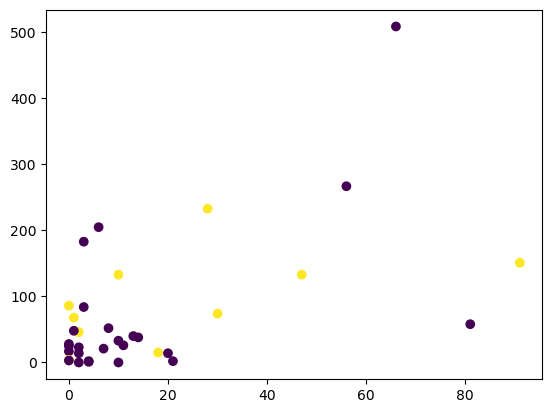

In [186]:
plt.scatter(df['am'], df['pm'], c=df['target'])

#### 2. Add the decision boundary of logistic regression to the plot.


В логистической регрессии для бинарной классификации с двумя признаками (например, x1 и x2) уравнение модели можно записать следующим образом:
h(x)=σ(w1x1+w2x2+b)

Для определения границы, где модель принимает решение о принадлежности к классу, мы устанавливаем:
h(x)=0.5
Это соответствует уравнению:
w1x1+w2x2+b=0
Преобразование уравнения
Теперь мы можем выразить одно из значений через другое. Например, если мы хотим выразить x2 через x1:

    Переписываем уравнение:
     w2x2=−(w1x1+b)
    Делим обе стороны на w2:
       x2=−(w1/w2)x1−(b/w2)

In [187]:
lr = LogisticRegression(random_state=21, fit_intercept=False)

In [188]:
lr.fit(df[['am', 'pm']], df['target'])

LogisticRegression(fit_intercept=False, random_state=21)

In [189]:
w = lr.coef_[0]
w

array([ 0.00038653, -0.00298066])

In [190]:
b = lr.intercept_[0]
b

0.0

In [191]:
x_for_bound = np.array([df['am'].min(), df['am'].max()])

In [192]:
x_for_bound

array([ 0, 91])

In [193]:
y_for_bound = -1 * (w[0] / w[1]) * x_for_bound - (b / w[1])

In [194]:
y_for_bound

array([ 0.        , 11.80072628])

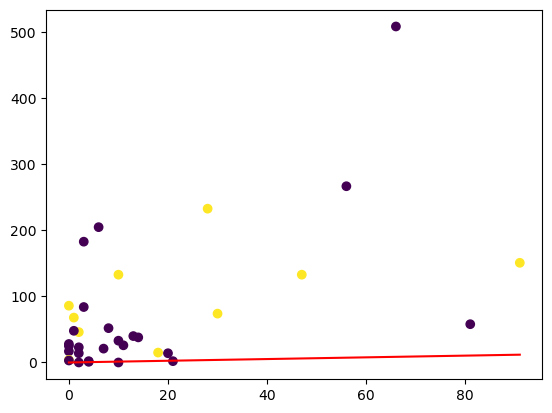

In [195]:
plt.scatter(df['am'], df['pm'], c=df['target'])
plt.plot(x_for_bound, y_for_bound, c='red')

#### 3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.


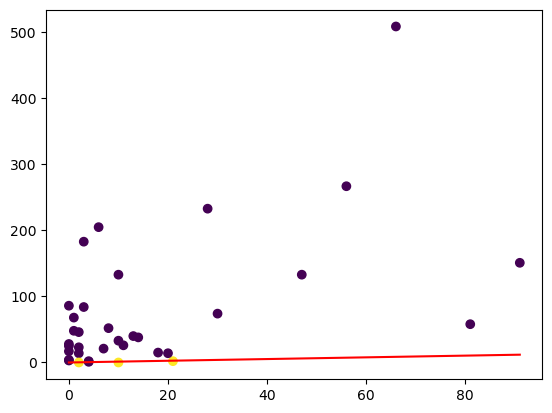

In [196]:
plt.scatter(df['am'], df['pm'], c=df['predict'])
plt.plot(x_for_bound, y_for_bound, c='red')

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

#### 1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.


In [197]:
X = df[['am', 'pm']]

In [198]:
scaler = StandardScaler()
scaler.fit(X)

StandardScaler()

In [199]:
X

,am,pm
0,21,2
1,1,68
2,18,15
3,2,23
4,0,25
5,0,28
6,10,33
7,2,14
8,30,74
9,28,233


In [200]:
X_scaled = pd.DataFrame(data=scaler.transform(X), columns=X.columns)

In [201]:
X_scaled

,am,pm
0,0.200690,-0.719904
1,-0.655914,-0.071822
2,0.072199,-0.592251
3,-0.613084,-0.513696
4,-0.698744,-0.494057
5,-0.698744,-0.464599
6,-0.270442,-0.415502
7,-0.613084,-0.602071
8,0.586162,-0.012906
9,0.500501,1.548382


In [202]:
lr.fit(X_scaled, df['target'])

LogisticRegression(fit_intercept=False, random_state=21)

In [203]:
pred = lr.predict(X_scaled)

#### 2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?


In [204]:
accuracy_score(df['target'], pred)

0.7428571428571429

In [205]:
accuracy_score(df['target'], [df['target'].mode()[0]] * df.shape[0])

0.7142857142857143

Answer: yes, it got better.

#### 3. Draw the plots that were described above but for the new model.

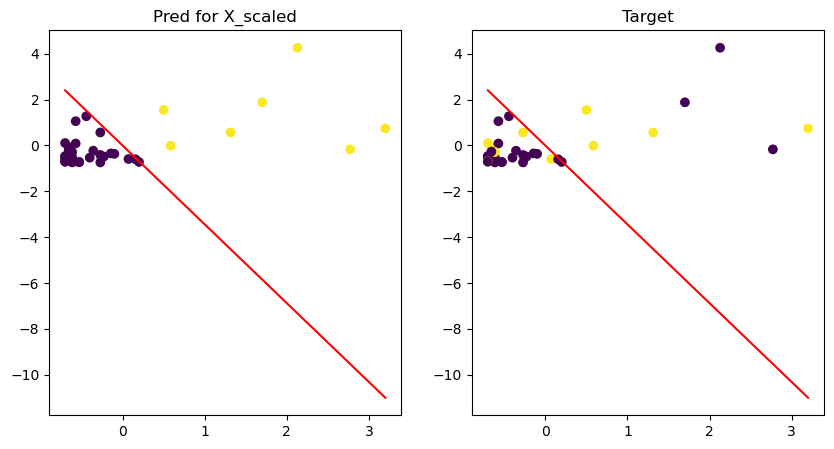

In [206]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

w = lr.coef_[0]
b = lr.intercept_[0]
x_for_bound = np.array([X_scaled['am'].min(), X_scaled['am'].max()])
y_for_bound = -1 * (w[0] / w[1]) * x_for_bound - (b / w[1])

axes[0].set_title('Pred for X_scaled')
axes[0].scatter(X_scaled['am'], X_scaled['pm'], c=pred)
axes[0].plot(x_for_bound, y_for_bound, c='red')

axes[1].set_title('Target')
axes[1].scatter(X_scaled['am'], X_scaled['pm'], c=df['target'])
axes[1].plot(x_for_bound, y_for_bound, c='red')

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [207]:
X_scaled

,am,pm
0,0.200690,-0.719904
1,-0.655914,-0.071822
2,0.072199,-0.592251
3,-0.613084,-0.513696
4,-0.698744,-0.494057
5,-0.698744,-0.464599
6,-0.270442,-0.415502
7,-0.613084,-0.602071
8,0.586162,-0.012906
9,0.500501,1.548382


In [208]:
y = df['target']

In [209]:
y

0     0
1     1
2     1
3     0
4     0
5     0
6     0
7     0
8     1
9     1
10    0
11    0
12    0
13    0
14    0
15    1
16    1
17    0
18    0
19    0
20    0
21    0
22    1
23    1
24    0
25    0
26    0
27    0
28    0
29    1
30    1
31    0
32    0
33    0
34    0
Name: target, dtype: int64

#### 1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.

In [210]:
svc = SVC(probability=True, random_state=21)
svc.fit(X_scaled, y)

SVC(probability=True, random_state=21)

In [211]:
pred = svc.predict(X_scaled)

In [212]:
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### 2. Calculate `accuracy`.

In [213]:
accuracy_score(y, pred)

0.7428571428571429

#### 3. Try different kernels, find the best in terms of accuracy.

In [214]:
# linear
svc = SVC(probability=True, random_state=21, kernel='linear')
svc.fit(X_scaled, y)
pred = svc.predict(X_scaled)
accuracy_score(y, pred)

0.7142857142857143

In [215]:
# poly
svc = SVC(probability=True, random_state=21, kernel='poly')
svc.fit(X_scaled, y)
pred = svc.predict(X_scaled)
accuracy_score(y, pred)

0.7428571428571429

In [216]:
# sigmoid
svc = SVC(probability=True, random_state=21, kernel='sigmoid')
svc.fit(X_scaled, y)
pred = svc.predict(X_scaled)
accuracy_score(y, pred)

0.6857142857142857

In [217]:
# rbf
svc = SVC(probability=True, random_state=21, kernel='rbf')
svc.fit(X_scaled, y)
pred = svc.predict(X_scaled)
accuracy_score(y, pred)

0.7428571428571429

The best kernels: poly, rbf.

#### 4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [218]:
# poly
svc = SVC(probability=True, random_state=21, kernel='poly')
svc.fit(X_scaled, y)
pred = svc.predict(X_scaled)
accuracy_score(y, pred)

0.7428571428571429

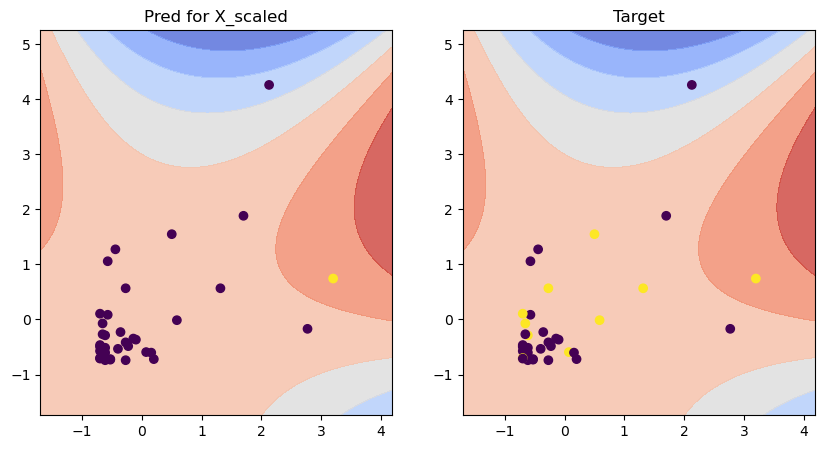

In [219]:
# Создаем сетку для отображения разделяющей поверхности
x_min, x_max = X_scaled['am'].min() - 1, X_scaled['am'].max() + 1
y_min, y_max = X_scaled['pm'].min() - 1, X_scaled['pm'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Предсказываем значения для сетки
grid_points = pd.DataFrame({'am': xx.ravel(), 'pm': yy.ravel()})
Z = svc.decision_function(grid_points)
Z = Z.reshape(xx.shape)

# Создаем графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# График для предсказаний
axes[0].set_title('Pred for X_scaled')
axes[0].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[0].scatter(X_scaled['am'], X_scaled['pm'], c=pred)

# График для целевых значений
axes[1].set_title('Target')
axes[1].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[1].scatter(X_scaled['am'], X_scaled['pm'], c=df['target'])

plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

#### 1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.


In [220]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

In [221]:
dt.fit(X_scaled, y)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [222]:
pred = dt.predict(X_scaled)

#### 2. Calculate accuracy.


In [223]:
accuracy_score(y, pred)

0.9428571428571428

#### 3. Try different values of `max_depth`.


In [224]:
max_acc = 0
for depth in range(1, 10):
    max_depth = depth
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_scaled, y)
    pred = dt.predict(X_scaled)
    acc = accuracy_score(y, pred)
    if acc > max_acc:
        max_acc = acc
        best_depth = max_depth
    if acc == 1.0:
        break
print(f'Max accuracy: {max_acc}, best max_depth: {best_depth}')

Max accuracy: 1.0, best max_depth: 6


#### 4. Draw both plots again with the decisions boundary to see how this algorithm works.


In [225]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_scaled, y)
pred = dt.predict(X_scaled)

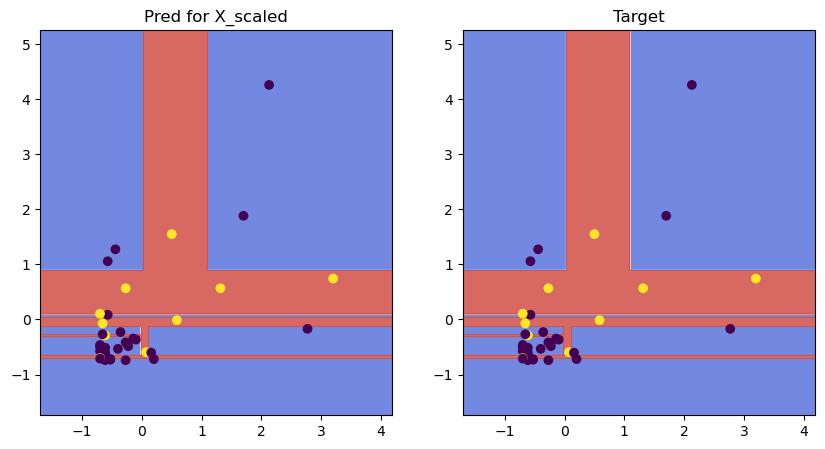

In [226]:
# Создаем сетку для отображения разделяющей поверхности
x_min, x_max = X_scaled['am'].min() - 1, X_scaled['am'].max() + 1
y_min, y_max = X_scaled['pm'].min() - 1, X_scaled['pm'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Предсказываем значения для сетки
grid_points = pd.DataFrame({'am': xx.ravel(), 'pm': yy.ravel()})
Z = dt.predict(grid_points)
Z = Z.reshape(xx.shape)

# Создаем графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# График для предсказаний
axes[0].set_title('Pred for X_scaled')
axes[0].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[0].scatter(X_scaled['am'], X_scaled['pm'], c=pred)

# График для целевых значений
axes[1].set_title('Target')
axes[1].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[1].scatter(X_scaled['am'], X_scaled['pm'], c=df['target'])

plt.show()

#### 5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.


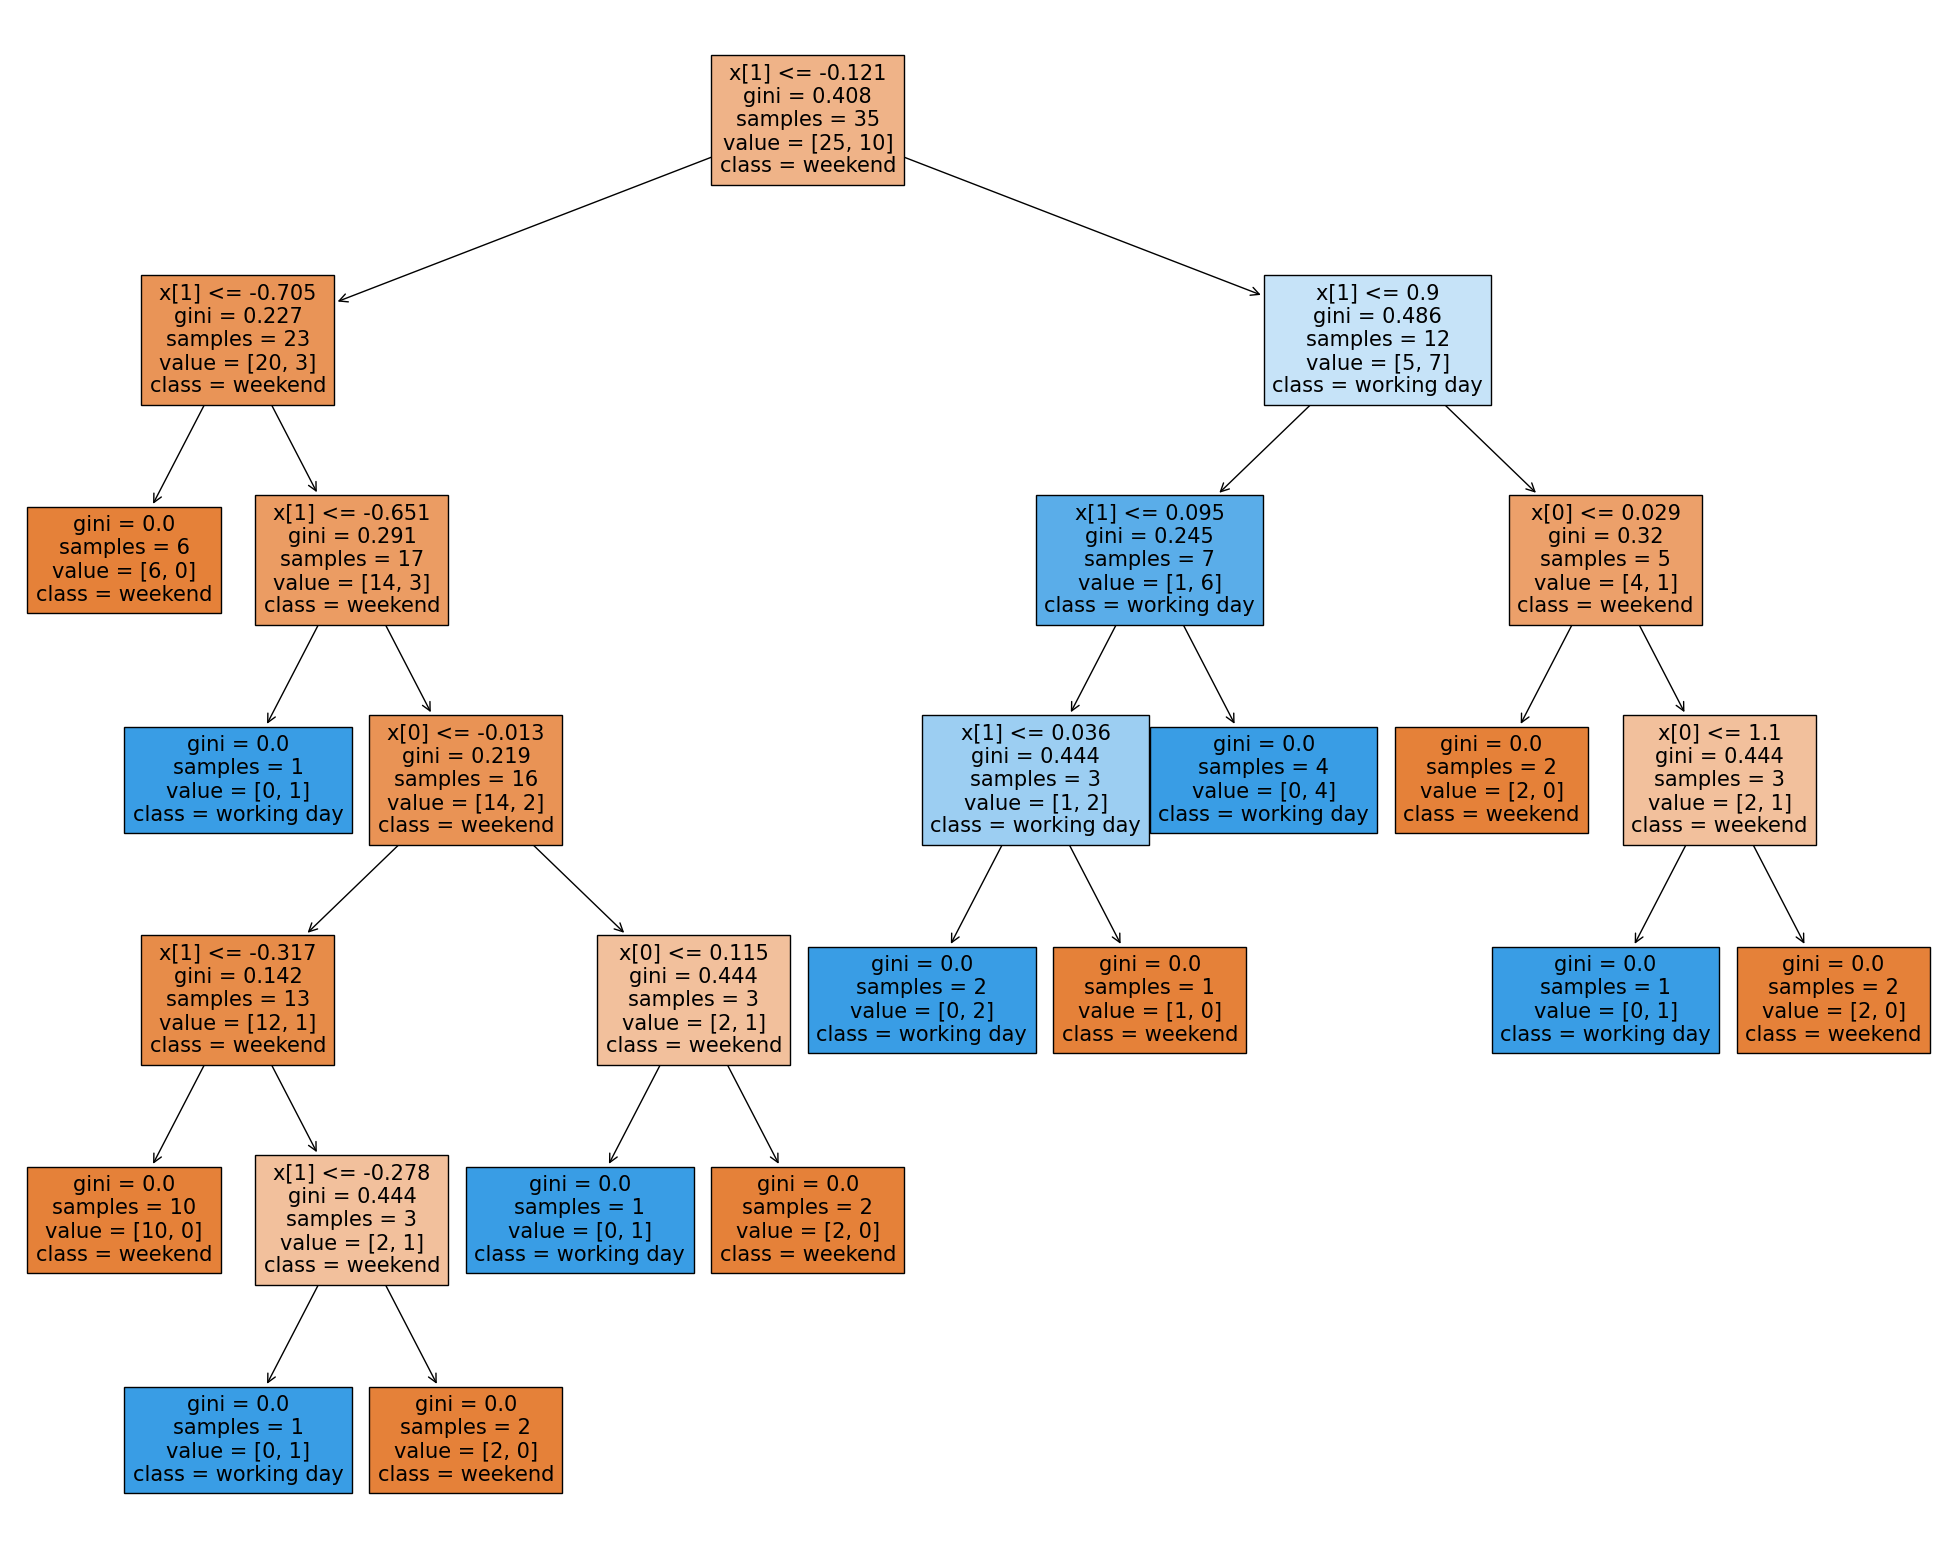

In [227]:
plt.figure(figsize=(25,20), dpi=100)
plot_tree(dt,
          class_names=['weekend', 'working day'],
          filled=True)
plt.show()

#### 6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

Answer: 6 leaves.